In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import cv2 as cv2

In [2]:
path_to_data = '/kaggle/input/mango-leaf-disease-detection-raw-augmented-data'

In [3]:
data = []
labels = []

img_size = (224, 224)
for folder in os.listdir(path_to_data):
    print(folder)
    for file in os.listdir(os.path.join(path_to_data, folder)):
        img_path = os.path.join(path_to_data, folder, file)
        img = cv2.imread(img_path, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, img_size)
        data.append(img)
        labels.append(folder)

# Convert to NumPy arrays if needed
data = np.array(data, dtype=np.float32)
labels = np.array(labels)

gall_midge
anthracnose
die_black
powdery_mildew
healthy


In [4]:
# Normalization
data = data/255.0

In [5]:
data[0]

array([[[0.6039216 , 0.59607846, 0.57254905],
        [0.60784316, 0.6       , 0.5764706 ],
        [0.60784316, 0.6       , 0.5764706 ],
        ...,
        [0.6392157 , 0.62352943, 0.61960787],
        [0.63529414, 0.61960787, 0.61960787],
        [0.6313726 , 0.61960787, 0.6117647 ]],

       [[0.6039216 , 0.59607846, 0.57254905],
        [0.60784316, 0.6       , 0.5764706 ],
        [0.60784316, 0.6       , 0.5764706 ],
        ...,
        [0.6392157 , 0.627451  , 0.62352943],
        [0.6392157 , 0.62352943, 0.61960787],
        [0.63529414, 0.61960787, 0.61960787]],

       [[0.6039216 , 0.59607846, 0.57254905],
        [0.60784316, 0.6       , 0.5764706 ],
        [0.60784316, 0.6       , 0.5764706 ],
        ...,
        [0.6392157 , 0.62352943, 0.61960787],
        [0.6392157 , 0.62352943, 0.61960787],
        [0.6392157 , 0.62352943, 0.61960787]],

       ...,

       [[0.7137255 , 0.69803923, 0.68235296],
        [0.7137255 , 0.69803923, 0.68235296],
        [0.7176471 , 0

In [6]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Fit and transform labels
encoded_labels = label_encoder.fit_transform(labels)

# Create mapping of original labels to encoded values
label_mapping = dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))

# Print the mapping
print("Label Mapping:")
for original, encoded in label_mapping.items():
    print(f"{original} -> {encoded}")

# Print the transformed labels
print("\nEncoded Labels:")
print(encoded_labels)

Label Mapping:
anthracnose -> 0
die_black -> 1
gall_midge -> 2
healthy -> 3
powdery_mildew -> 4

Encoded Labels:
[2 2 2 ... 3 3 3]


In [7]:
np.unique(encoded_labels)

array([0, 1, 2, 3, 4])

In [8]:
data[0]

array([[[0.6039216 , 0.59607846, 0.57254905],
        [0.60784316, 0.6       , 0.5764706 ],
        [0.60784316, 0.6       , 0.5764706 ],
        ...,
        [0.6392157 , 0.62352943, 0.61960787],
        [0.63529414, 0.61960787, 0.61960787],
        [0.6313726 , 0.61960787, 0.6117647 ]],

       [[0.6039216 , 0.59607846, 0.57254905],
        [0.60784316, 0.6       , 0.5764706 ],
        [0.60784316, 0.6       , 0.5764706 ],
        ...,
        [0.6392157 , 0.627451  , 0.62352943],
        [0.6392157 , 0.62352943, 0.61960787],
        [0.63529414, 0.61960787, 0.61960787]],

       [[0.6039216 , 0.59607846, 0.57254905],
        [0.60784316, 0.6       , 0.5764706 ],
        [0.60784316, 0.6       , 0.5764706 ],
        ...,
        [0.6392157 , 0.62352943, 0.61960787],
        [0.6392157 , 0.62352943, 0.61960787],
        [0.6392157 , 0.62352943, 0.61960787]],

       ...,

       [[0.7137255 , 0.69803923, 0.68235296],
        [0.7137255 , 0.69803923, 0.68235296],
        [0.7176471 , 0

In [ ]:
import random
import matplotlib.pyplot as plt
import numpy as np

# Define label mapping
label_mapping = {
    0: "Anthracnose",
    1: "Die Black",
    2: "Gall Midge",
    3: "Healthy",
    4: "Powdery Mildew"
}

# Sample 5 random indices from each class
r_b = random.sample(list(np.where(encoded_labels == 0)[0]), 5)
r_f = random.sample(list(np.where(encoded_labels == 1)[0]), 5)
r_g = random.sample(list(np.where(encoded_labels == 2)[0]), 5)
r_m = random.sample(list(np.where(encoded_labels == 3)[0]), 5)
r_se = random.sample(list(np.where(encoded_labels == 4)[0]), 5)

# Combine the selected indices and reshape into a 5x5 grid
plots = np.array(r_b + r_f + r_g + r_m + r_se).reshape(5, 5)

# Create subplots
fig, ax = plt.subplots(5, 5, figsize=(10, 10))
fig.subplots_adjust(hspace=0.5, wspace=0.5)  # Adjust spacing

# Plot images with corresponding class names
for i in range(5):
    for j in range(5):
        idx = plots[i, j]
        ax[i, j].imshow(data[idx])  # RGB images, so no cmap='gray'
        ax[i, j].set_title(f"{label_mapping[encoded_labels[idx]]}", fontsize=8)
        ax[i, j].axis('off')

plt.show()


In [ ]:
# Flatten each color channel
red_values = data[:, :, :, 0].ravel()   # Red channel
green_values = data[:, :, :, 1].ravel() # Green channel
blue_values = data[:, :, :, 2].ravel()  # Blue channel

# Plot histograms
plt.figure(figsize=(12, 6))
plt.hist(red_values, bins=256, color='red', alpha=0.6, label="Red Channel")
plt.hist(green_values, bins=256, color='green', alpha=0.6, label="Green Channel")
plt.hist(blue_values, bins=256, color='blue', alpha=0.6, label="Blue Channel")

# Labels and Title
plt.xlabel("Pixel Intensity (0-255)")
plt.ylabel("Frequency")
plt.title("RGB Histogram of All Images")
plt.legend()
plt.show()

In [ ]:
# Count occurrences of each label
unique_labels, label_counts = np.unique(encoded_labels, return_counts=True)

# Create a bar plot
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=unique_labels, y=label_counts, palette="viridis")

# Add count labels on top of each bar
for i, count in enumerate(label_counts):
    ax.text(i, count + 0.5, str(count), ha='center', fontsize=12, fontweight='bold')

# Labels and title
plt.xlabel("Labels")
plt.ylabel("Count")
plt.title("Distribution of Encoded Labels")
plt.show()

In [9]:
from sklearn.model_selection import train_test_split
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(data, encoded_labels, test_size=0.2, random_state=42, shuffle=True)

# Ensure correct shape for RGB images
X_train = X_train.reshape(-1, 224, 224, 3)
X_test = X_test.reshape(-1, 224, 224, 3)

# Define number of classes
num_classes = len(np.unique(encoded_labels))

print("Number of classes:", num_classes)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Number of classes: 5
X_train shape: (6984, 224, 224, 3)
X_test shape: (1746, 224, 224, 3)


In [10]:
print("Unique classes in y_train:", np.unique(y_train))
print("Unique classes in y_test:", np.unique(y_test))
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


Unique classes in y_train: [0 1 2 3 4]
Unique classes in y_test: [0 1 2 3 4]
y_train shape: (6984,)
y_test shape: (1746,)


# ResNet-50

In [15]:
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Activation, MaxPooling2D, AveragePooling2D, Add, Flatten, Dense,ZeroPadding2D
from tensorflow.keras.models import Model
from tensorflow.keras.initializers import glorot_uniform
import tensorflow as tf

In [12]:
def identity_block(X, f, filters, stage, block):
    # defining name basis
    conv_name_base = 'res' + str(stage) + block + '_branch'
    bn_name_base = 'bn' + str(stage) + block + '_branch'

    # Retrieve Filters
    F1, F2, F3 = filters

    # Saving the input value
    X_shortcut = X

    # First component of main path
    X = Conv2D(filters = F1, kernel_size = (1, 1), strides = (1,1), padding = 'valid', name = conv_name_base + '2a')(X)
    X = BatchNormalization(axis = 3, name = bn_name_base + '2a')(X)
    X = Activation('relu')(X)

    # Second component of main path
    X = Conv2D(filters = F2, kernel_size = (f, f), strides = (1,1), padding = 'same', name = conv_name_base + '2b')(X)
    X = BatchNormalization(axis = 3, name = bn_name_base + '2b')(X)
    X = Activation('relu')(X)

    # Third component of main path
    X = Conv2D(filters = F3, kernel_size = (1, 1), strides = (1,1), padding = 'valid', name = conv_name_base + '2c')(X)
    X = BatchNormalization(axis = 3, name = bn_name_base + '2c')(X)

    # Final step: Add shortcut value to main path, and pass it through a RELU activation
    X = Add()([X, X_shortcut])
    X = Activation('relu')(X)

    return X

def convolutional_block(X, f, filters, stage, block, s = 2):
    # defining name basis
    conv_name_base = 'res' + str(stage) + block + '_branch'
    bn_name_base = 'bn' + str(stage) + block + '_branch'

    # Retrieve Filters
    F1, F2, F3 = filters

    # Save the input value
    X_shortcut = X

    # First layer
    X = Conv2D(F1, (1, 1), strides = (s,s), name = conv_name_base + '2a')(X)
    X = BatchNormalization(axis = 3, name = bn_name_base + '2a')(X)
    X = Activation('relu')(X)

    # Second layer
    X = Conv2D(filters = F2, kernel_size = (f, f), strides = (1,1), padding = 'same', name = conv_name_base + '2b')(X)
    X = BatchNormalization(axis = 3, name = bn_name_base + '2b')(X)
    X = Activation('relu')(X)

    # Third layer
    X = Conv2D(filters = F3, kernel_size = (1, 1), strides = (1,1), padding = 'valid', name = conv_name_base + '2c')(X)
    X = BatchNormalization(axis = 3, name = bn_name_base + '2c')(X)

    # Shortcut path
    X_shortcut = Conv2D(filters = F3, kernel_size = (1, 1), strides = (s,s), padding = 'valid', name = conv_name_base + '1')(X_shortcut)
    X_shortcut = BatchNormalization(axis = 3, name = bn_name_base + '1')(X_shortcut)

    # Final step: Add shortcut value here, and pass it through a RELU activation
    X = Add()([X, X_shortcut])
    X = Activation('relu')(X)

    return X
def ResNet50(input_shape=(64, 64, 1), classes=5):
    """
    Implementation of the ResNet50 architecture:
    CONV2D -> BATCHNORM -> RELU -> MAXPOOL -> CONVBLOCK -> IDBLOCK*2 -> CONVBLOCK -> IDBLOCK*3
    -> CONVBLOCK -> IDBLOCK*5 -> CONVBLOCK -> IDBLOCK*2 -> AVGPOOL -> TOPLAYER
    """

    # Define the input as a tensor with shape input_shape
    X_input = Input(input_shape)

    # Zero-Padding
    X = ZeroPadding2D((3, 3))(X_input)

    # Stage 1
    X = Conv2D(64, (7, 7), strides=(2, 2), name='conv1')(X)
    X = BatchNormalization(axis=3, name='bn_conv1')(X)
    X = Activation('relu')(X)
    X = MaxPooling2D((3, 3), strides=(2, 2))(X)

    # Stage 2
    X = convolutional_block(X, f=3, filters=[64, 64, 256], stage=2, block='a', s=1)
    X = identity_block(X, 3, [64, 64, 256], stage=2, block='b')
    X = identity_block(X, 3, [64, 64, 256], stage=2, block='c')

    # Stage 3
    X = convolutional_block(X, f=3, filters=[128, 128, 512], stage=3, block='a', s=2)
    X = identity_block(X, 3, [128, 128, 512], stage=3, block='b')
    X = identity_block(X, 3, [128, 128, 512], stage=3, block='c')
    X = identity_block(X, 3, [128, 128, 512], stage=3, block='d')

    # Stage 4
    X = convolutional_block(X, f=3, filters=[256, 256, 1024], stage=4, block='a', s=2)
    X = identity_block(X, 3, [256, 256, 1024], stage=4, block='b')
    X = identity_block(X, 3, [256, 256, 1024], stage=4, block='c')
    X = identity_block(X, 3, [256, 256, 1024], stage=4, block='d')
    X = identity_block(X, 3, [256, 256, 1024], stage=4, block='e')
    X = identity_block(X, 3, [256, 256, 1024], stage=4, block='f')

    # Stage 5
    X = convolutional_block(X, f=3, filters=[512, 512, 2048], stage=5, block='a', s=2)
    X = identity_block(X, 3, [512, 512, 2048], stage=5, block='b')
    X = identity_block(X, 3, [512, 512, 2048], stage=5, block='c')

    # AVGPOOL
    X = AveragePooling2D((2,2), name="avg_pool")(X)

    # Output layer
    X = Flatten()(X)
    X = Dense(classes, activation='softmax', name='fc' + str(classes), kernel_initializer=glorot_uniform(seed=0))(X)

    # Create model
    model = Model(inputs=X_input, outputs=X, name='ResNet50')

    return model

model5 = ResNet50(input_shape=(224, 224, 3), classes=5)

In [16]:
model5.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [17]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Define the path where the model with the best parameters will be saved
checkpoint_path = "best_model.keras"

# Create a callback that saves the model with the best validation accuracy
checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_accuracy',  # Monitor validation accuracy
    save_best_only=True,
    save_weights_only=False,
    mode='max',  # Save when val_accuracy is maximized
    verbose=1
)

# Create an EarlyStopping callback with patience=5
early_stopping_callback = EarlyStopping(
    monitor='val_accuracy',  # Monitor validation accuracy
    patience=10,  # Stop training if no improvement after 10 epochs
    mode='max',  # Check for maximization of val_accuracy
    verbose=1,
    restore_best_weights=True  # Restore model weights from the epoch with the best validation accuracy
)

# Train the model with the checkpoint and early stopping callbacks
history5 = model5.fit(X_train, y_train,
                    validation_split=0.2,
                    epochs=50,
                    batch_size=32,
                    callbacks=[checkpoint_callback, early_stopping_callback])


Epoch 1/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.3520 - loss: 3.8422
Epoch 1: val_accuracy improved from -inf to 0.21618, saving model to best_model.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 115s 460ms/step - accuracy: 0.3526 - loss: 3.8362 - val_accuracy: 0.2162 - val_loss: 2.8313
Epoch 2/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step - accuracy: 0.6752 - loss: 1.2412
Epoch 2: val_accuracy improved from 0.21618 to 0.47101, saving model to best_model.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 61s 346ms/step - accuracy: 0.6754 - loss: 1.2404 - val_accuracy: 0.4710 - val_loss: 1.9853
Epoch 3/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - accuracy: 0.7919 - loss: 0.6957
Epoch 3: val_accuracy improved from 0.47101 to 0.68361, saving model to best_model.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 64s 368ms/step - accuracy: 0.7920 - loss: 0.6953 - val_accuracy: 0.6836 - val_loss: 1.3283
Epoch 4/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - accuracy: 0.8630 - loss: 0.4038
Epoch 4: val_accuracy i

55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step
Test Accuracy: 0.9863
Test Precision: 0.9872
Test Recall (Sensitivity): 0.9858
Test Specificity: 0.9872
Test F1 Score: 0.9864

Classification Report:
                 precision    recall  f1-score   support

   anthracnose       0.99      0.98      0.99       321
     die_black       0.99      1.00      0.99       434
    gall_midge       0.98      0.97      0.97       399
       healthy       0.98      1.00      0.99       338
powdery_mildew       1.00      0.98      0.99       254

      accuracy                           0.99      1746
     macro avg       0.99      0.99      0.99      1746
  weighted avg       0.99      0.99      0.99      1746



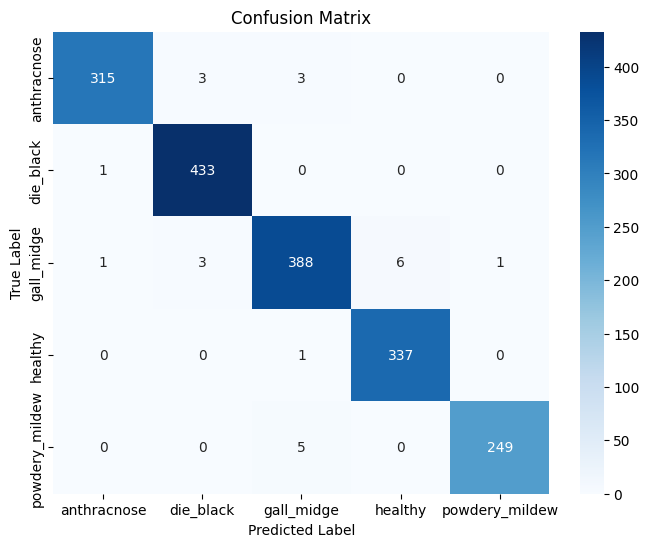

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Labels
class_labels = ['anthracnose', 'die_black', 'gall_midge', 'healthy', 'powdery_mildew']

# Predict class probabilities
y_pred_probs = model5.predict(X_test)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred_probs, axis=1)

# Ensure y_test is in correct format
if len(y_test.shape) > 1 and y_test.shape[1] > 1:  # If one-hot encoded
    y_true = np.argmax(y_test, axis=1)  # Convert to class labels
else:  
    y_true = y_test  # Already in label format

# Compute accuracy, precision, recall, and F1 score
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

# Compute Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Compute Sensitivity and Specificity for Multi-Class
class_sensitivity = np.diag(cm) / np.sum(cm, axis=1)  # Sensitivity per class
class_specificity = np.diag(cm) / np.sum(cm, axis=0)  # Specificity per class
sensitivity = np.mean(class_sensitivity)  # Mean Sensitivity
specificity = np.mean(class_specificity)  # Mean Specificity

# Print Evaluation Metrics
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall (Sensitivity): {sensitivity:.4f}")
print(f"Test Specificity: {specificity:.4f}")
print(f"Test F1 Score: {f1:.4f}")
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=class_labels))

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


In [20]:
model5.save('/kaggle/working/ResNet-50.keras')